In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [8]:
from google.colab import files

uploaded = files.upload()

Saving healthcare_dataset.csv to healthcare_dataset.csv


In [9]:
df = pd.read_csv("/content/healthcare_dataset.csv")

In [10]:
df.head()

,Patient_ID,Gender,Age,Medical_Condition,Admission_Date,Admission_Type,Medical_Code,Billing_Amount,Discharge_Date
0,P1001,Male,45,Hypertension,15-01-2026,Urgent,ICD10 I10,4500.0,20-01-2026
1,P1002,Female,32,Pneumonia,16-01-2026,Emergency,ICD10 J18,6700.5,22-01-2026
2,P1003,Male,68,Diabetes Type 2,16-01-2026,Routine,ICD10 E11,3200.0,18-01-2026
3,P1004,Female,55,Asthma,17-01-2026,Emergency,ICD10 J45,5800.0,19-01-2026
4,P1005,Male,29,Fracture,17-01-2026,Urgent,ICD10 S52,8500.0,25-01-2026


In [11]:
df.columns

Index(['Patient_ID', 'Gender', 'Age', 'Medical_Condition', 'Admission_Date',
       'Admission_Type', 'Medical_Code', 'Billing_Amount', 'Discharge_Date'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Patient_ID         500 non-null    object 
 1   Gender             500 non-null    object 
 2   Age                500 non-null    int64  
 3   Medical_Condition  500 non-null    object 
 4   Admission_Date     500 non-null    object 
 5   Admission_Type     500 non-null    object 
 6   Medical_Code       485 non-null    object 
 7   Billing_Amount     500 non-null    float64
 8   Discharge_Date     500 non-null    object 
dtypes: float64(1), int64(1), object(7)
memory usage: 35.3+ KB


In [13]:
df.isnull()

,Patient_ID,Gender,Age,Medical_Condition,Admission_Date,Admission_Type,Medical_Code,Billing_Amount,Discharge_Date
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
495,False,False,False,False,False,False,False,False,False
496,False,False,False,False,False,False,False,False,False
497,False,False,False,False,False,False,False,False,False
498,False,False,False,False,False,False,False,False,False


In [14]:
df['Medical_Code'].isnull().sum()

np.int64(15)

In [15]:
df['Medical_Code']=df['Medical_Code'].fillna('unknown')

In [16]:
df['Admission_Date']=pd.to_datetime(df['Admission_Date'])
df['Admission_Date']

/tmp/ipykernel_448/4191176909.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Admission_Date']=pd.to_datetime(df['Admission_Date'])


,Admission_Date
0,2026-01-15
1,2026-01-16
2,2026-01-16
3,2026-01-17
4,2026-01-17
...,...
495,2026-09-20
496,2026-09-20
497,2026-09-21
498,2026-09-21


In [17]:
df['Discharge_Date']=pd.to_datetime(df['Discharge_Date'], format='%d-%m-%Y')
df['Discharge_Date']

,Discharge_Date
0,2026-01-20
1,2026-01-22
2,2026-01-18
3,2026-01-19
4,2026-01-25
...,...
495,2026-09-23
496,2026-09-24
497,2026-09-25
498,2026-09-23


In [18]:
df['Admission_Type']=(
    df['Admission_Type']
    .str.strip()
    .str.lower()
    .str.title()
)
df['Admission_Type']

,Admission_Type
0,Urgent
1,Emergency
2,Routine
3,Emergency
4,Urgent
...,...
495,Emergency
496,Urgent
497,Emergency
498,Routine


In [19]:
df['Billing_Amount'].describe()

,Billing_Amount
count,500.00000
mean,7249.00100
std,3198.96932
min,2300.00000
25%,4400.00000
50%,6950.00000
75%,9400.00000
max,14200.00000


In [20]:
import seaborn as sns

In [21]:
billing = df.groupby(['Medical_Condition', 'Gender'])['Billing_Amount'].sum().unstack()
billing

Gender,Female,Male
Medical_Condition,,
Allergic Reaction,55200.0,3600.0
Anxiety Disorder,6200.0,21600.0
Appendicitis,74700.0,244700.0
Asthma,43000.0,54900.0
Back Pain,21300.0,55500.0
COPD,141500.0,154700.0
Diabetes Type 1,58500.0,13800.0
Diabetes Type 2,23400.0,42800.0
Fracture,59200.0,129300.0


<Axes: xlabel='Medical_Condition'>

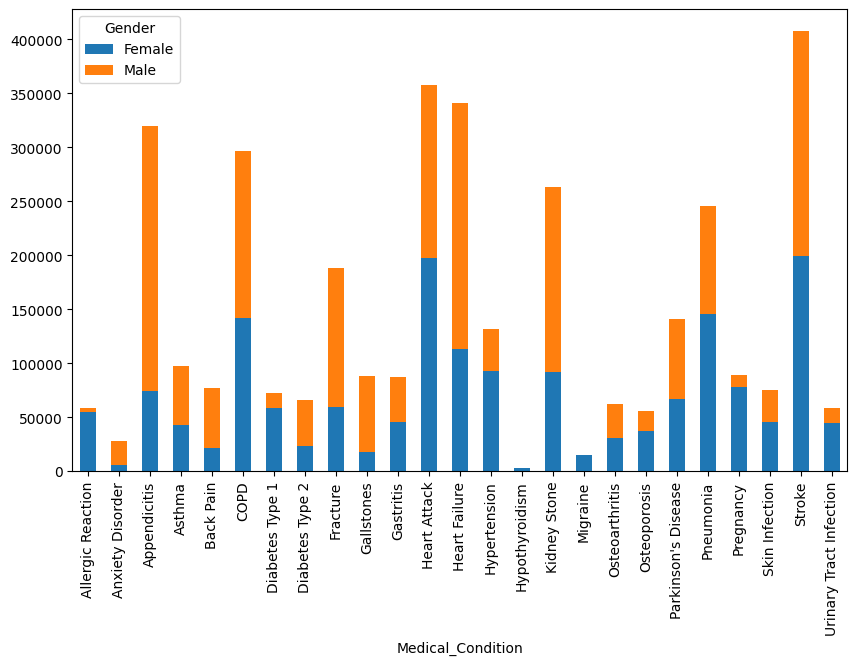

In [22]:
billing.plot(kind='bar',figsize=(10,6), stacked=True)

<Axes: xlabel='Medical_Condition', ylabel='Billing_Amount'>

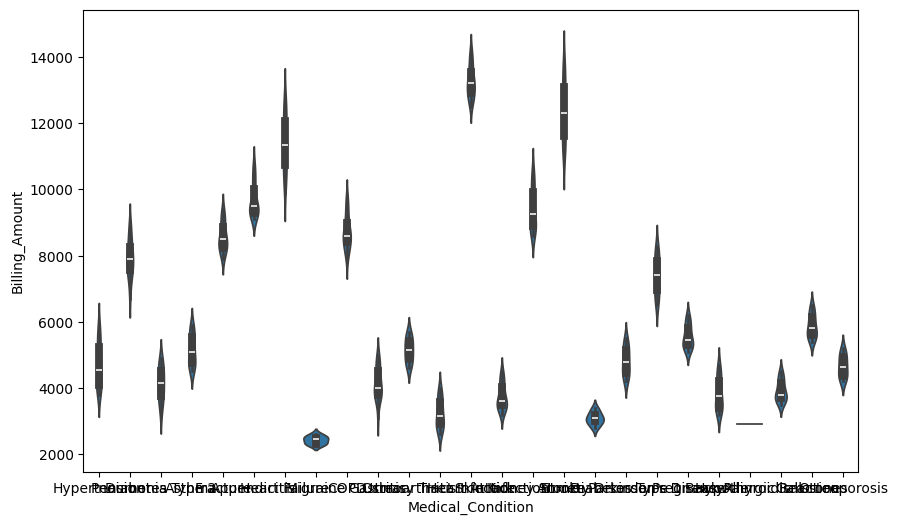

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.violinplot(data=df,
               x='Medical_Condition',
               y='Billing_Amount')

In [29]:
df['Admission_Month']=df['Admission_Date'].dt.month
df['Admission_Month']

,Admission_Month
0,1
1,1
2,1
3,1
4,1
...,...
495,9
496,9
497,9
498,9


<Axes: xlabel='Admission_Month'>

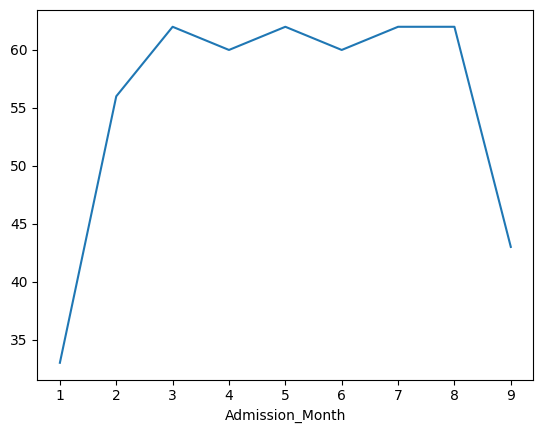

In [31]:
monthly_sub = df['Admission_Month'].value_counts().sort_index()
monthly_sub.plot()